# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

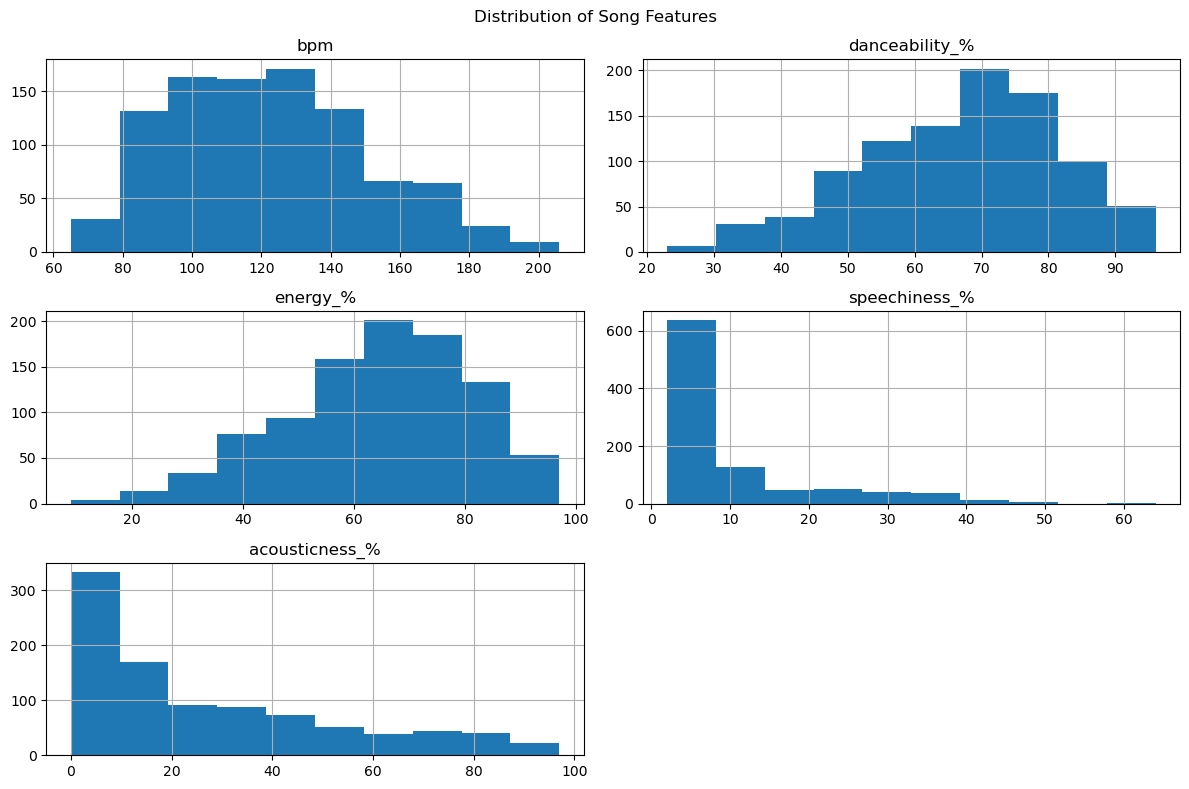

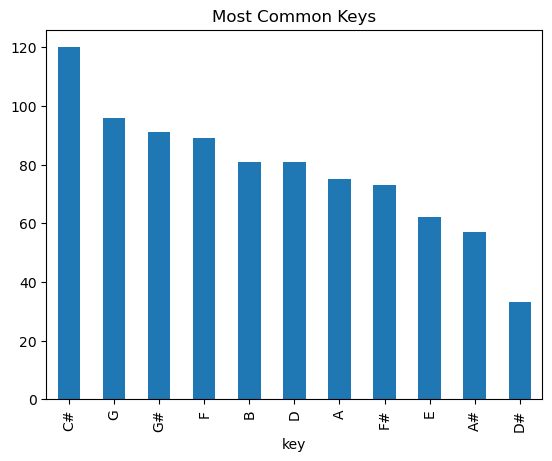

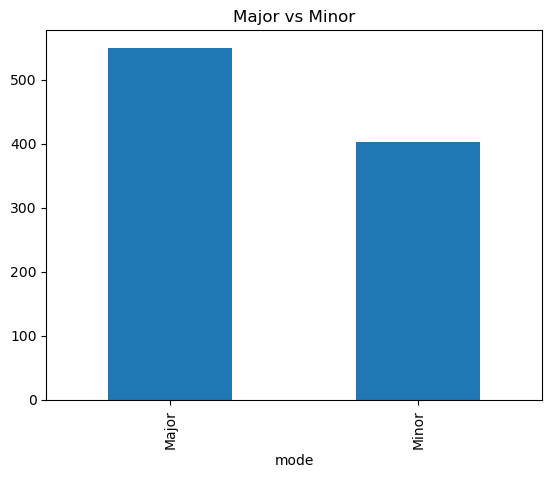

Average values:
bpm               122.540399
danceability_%     66.969570
energy_%           64.279119
speechiness_%      10.131165
acousticness_%     27.057712
dtype: float64

Most common key: C#
Most common mode: Major

BPM range (25th to 75th percentile):
0.25    100.0
0.75    140.0
Name: bpm, dtype: float64
             track_name artist(s)_name     streams
518        Need To Know       Doja Cat  1042568408
660  Ginseng Strip 2002      Yung Lean   240769997
         track_name artist(s)_name     streams  bpm key   mode  \
55  Blinding Lights     The Weeknd  3703895074  171  C#  Major   

    danceability_%  energy_%  speechiness_%  acousticness_%  
55              50        80              7               0  


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

df[['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].hist(figsize=(12, 8))
plt.suptitle('Distribution of Song Features')
plt.tight_layout()
plt.show()

df['key'].value_counts().plot(kind='bar', title='Most Common Keys')
plt.show()

df['mode'].value_counts().plot(kind='bar', title='Major vs Minor')
plt.show()

print('Average values:')
print(df[['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].mean())

print('\nMost common key:', df['key'].mode()[0])
print('Most common mode:', df['mode'].mode()[0])

print('\nBPM range (25th to 75th percentile):')
print(df['bpm'].quantile([0.25, 0.75]))

engineered_hits = df[
    (df['bpm'] >= 100) & (df['bpm'] <= 140) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'] >= 57) & (df['danceability_%'] <= 78) &
    (df['energy_%'] >= 53) & (df['energy_%'] <= 77) &
    (df['speechiness_%'] >= 4) & (df['speechiness_%'] <= 11) &
    (df['acousticness_%'] >= 6) & (df['acousticness_%'] <= 43)
]

print(engineered_hits[['track_name', 'artist(s)_name', 'streams']])

smash_hit = df[df['track_name'] == 'Blinding Lights']
print(smash_hit[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']])